In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from collections import Counter
import itertools
import os
import pickle
from datetime import datetime
import csv



import pandas as pd
import time
from copy import deepcopy


# 2. Add random_masking corrector from campbell et al.

In [2]:
def generate_mixture_parameters_dir(r, N, L, alpha, rng=None):
    """
    Generate parameters for a mixture of r product distributions over N variables
    with L states each. Each product component has independent Dirichlet(alpha) marginals.

    r: Number of mixture components
    N: Number of coordinates (dimensions)
    L: Number of discrete values each coorinate can take {0, ..., L-1}
    alpha: Total concentration parameter for Dirichlet distributions
    rng: Optional random number generator

    return tuple (w, mu) where
    w: shape (r,), mixture weights summing to 1
    mu: shape (r, N, L), mixture component marginals, for each component i, coordinate j,
            mu[i,j,:] ~ Dirichlet(alpha_vec) where alpha_vec = (alpha/L, ..., alpha/L)
    """
    if rng is None:
        rng = np.random.default_rng()


    w = np.full(r, 1.0 / r)

    # mu: shape (r, N, L), each entry is Dirichlet(alpha)
    mu = np.empty((r, N, L))
    alpha_vec = np.full(L, alpha/L)
    for i in range(r):
        for j in range(N):
            mu[i, j] = rng.dirichlet(alpha_vec)

    return w, mu

def sample_from_pi(w, mu, rng=None):
    """
    Sample x from the true mixture q(x) = sum_i w_i ∏_j mu[i,j,x_j].

    w: shape (r,)
    mu: shape (r, N, L)
    """
    if rng is None:
        rng = np.random.default_rng()

    w = np.asarray(w)
    mu = np.asarray(mu)
    r, N, L = mu.shape

    # pick mixture component
    i = rng.choice(r, p=w)

    # sample each coordinate independently
    x = np.empty(N, dtype=int)
    for j in range(N):
        x[j] = rng.choice(L, p=mu[i, j])

    return x

def _update_omega(omega, mu, block, x_vals, w=None, recompute=False):
    """
    Bayesian reweighting of the mixture posterior after revealing x_vals.
    
    Two modes:
    - recompute=False (default): incremental update, multiplies current omega
      by the likelihood of the newly revealed tokens in block:
        omega_i <- omega_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    - recompute=True: recomputes omega from scratch starting from prior w,
      using all coordinates in block. Used after corrector steps where some
      tokens may have been re-masked and omega needs to be resynced.
        omega_i <- w_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    
    Parameters
    ----------
    omega : np.ndarray, shape (r,)
        Current mixture posterior.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    block : list of int
        Coordinate indices to condition on.
    x_vals : np.ndarray, shape (N,)
        Current sequence state, used to look up x_vals[j] for j in block.
    w : np.ndarray, shape (r,), optional
        Prior mixture weights. Required if recompute=True.
    recompute : bool
        If True, recompute omega from scratch using prior w.
        If False, incrementally update current omega.
    
    Returns
    -------
    omega : np.ndarray, shape (r,)
        Updated (or recomputed) posterior weights.
    """
    if recompute:
        assert w is not None, "w must be provided when recompute=True"
        log_w = np.log(np.clip(w, 1e-300, None))
    else:
        log_w = np.log(np.clip(omega, 1e-300, None))
    
    for j in block:
        log_w += np.log(np.clip(mu[:, j, x_vals[j]], 1e-300, None))
    
    log_w -= logsumexp(log_w)
    return np.exp(log_w)

def tau_leap_step(x_t, w, mu, beta, t, tau, MASK=-1, rng=None, return_rates=False):
    """
    One reverse tau-leap step for masked diffusion using the 'keep last event'
    rule per coordinate.

    Assumptions
    -----------
    - Coordinates are conditionally independent within the leap once rates are fixed.
    - Unmasked coordinates stay unchanged in the reverse process.
    - For a masked coordinate d, reverse rates are
          lambda_{d,j} = c(t) * q(x0^d = j | x_t)
      with
          c(t) = beta * alpha_t / (1 - alpha_t),
          alpha_t = exp(-beta * t).

    Parameters
    ----------
    x_t : (N,) int array
        Current partially masked state.
    w   : (r,) array
        Mixture weights.
    mu  : (r, N, L) array
        Mixture component marginals.
    beta : float
        Constant masking rate.
    t : float
        Current time.
    tau : float
        Leap size.
    MASK : int
        Sentinel value used for masked coordinates.
    rng : np.random.Generator or None
    return_rates : bool
        If True, also return omega, lambda_mat, Lambda_vec.

    Returns
    -------
    x_next : (N,) int array
        State after one approximate reverse tau-leap.
    optionally:
    omega      : (r,) posterior component weights
    lambda_mat : (N, L) rates lambda_{d,j} (zeros for unmasked coords)
    Lambda_vec : (N,) total rates per coordinate
    """
    if rng is None:
        rng = np.random.default_rng()

    x_t = np.asarray(x_t, dtype=int)
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)

    r, N, L = mu.shape
    assert x_t.shape == (N,)

    alpha_t = np.exp(-beta * t)
    denom = max(1.0 - alpha_t, 1e-300)
    c_t = beta * alpha_t / denom

    unmasked_idx = [j for j in range(len(x_t)) if x_t[j] != MASK]
    omega = np.ones(r) / r
    omega = _update_omega(omega, mu, unmasked_idx, x_t, w=w, recompute=True)    

    x_next = x_t.copy()
    lambda_mat = np.zeros((N, L), dtype=float)
    Lambda_vec = np.zeros(N, dtype=float)

    masked_idx = np.where(x_t == MASK)[0]

    for d in masked_idx:
        # q(x0^d = j | x_t)
        p_d = omega @ mu[:, d, :] # posterior prob over possible tken values at coordinate d, given the currenlty visible coordinates
        p_d = np.clip(p_d, 0.0, None)
        p_d_sum = p_d.sum()
        if p_d_sum <= 0:
            continue
        p_d /= p_d_sum

        # reverse rates
        lam_d = c_t * p_d
        Lambda_d = lam_d.sum() # it stores only the possible trnasitionspaces, so not MASK hence we can sumall of them

        lambda_mat[d] = lam_d
        Lambda_vec[d] = Lambda_d

        # keep masked with probability exp(-tau * Lambda_d)
        if Lambda_d <= 0:
            print("NEGATIVE RATES FOUND")
            continue

        stay_prob = np.exp(-tau * Lambda_d)
        if rng.random() < stay_prob:
            x_next[d] = MASK
        else:
            x_next[d] = rng.choice(L, p=lam_d / Lambda_d) #chose the state withprob lam_d/Lam_d

    if return_rates:
        return x_next, omega, lambda_mat, Lambda_vec
    return x_next

def initialize_all_mask_particles(n_mc, N, MASK=-1):
    return np.full((n_mc, N), MASK, dtype=int)

def forward_marginal(x_t, beta, delta_t, rng=None):
    """
    Corrupt x_t to time t + delta_t using the forward masking process.
    Each coordinate j is masked independently with probability 1 - e^{-beta*(delta_t)}.
    
    Parameters
    ----------
    x_t : np.ndarray, shape (N,)
        Current sequence state, with MASK=-1
    beta : float
        Forward masking rate.
    delta_t : float
        Time to corrupt to.
    rng : np.random.Generator, optional
    
    Returns
    -------
    x_t_delta_t : np.ndarray, shape (N,)
        Corrupted sample with some coordinates masked.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    MASK = -1
    alpha_dt = np.exp(-beta * delta_t)
    x_t_delta_t = x_t.copy()
    mask = rng.random(len(x_t)) < (1 - alpha_dt)
    x_t_delta_t[mask] = MASK
    return x_t_delta_t

def pregenerate_forward_samples(w, mu, beta, T, tau, checkpoint_every, n_mc, rngs):
    """
    Pre-generate forward samples at checkpoint times.

    Returns
    -------
    x_forward : list of lists
        x_forward[m][k] is trajectory m at checkpoint k
    checkpoint_steps : list of int
        Step indices of checkpoints, including 0 and n_steps
    """
    n_steps = int(round(T / tau))

    checkpoint_steps = list(range(0, n_steps + 1, checkpoint_every))
    if checkpoint_steps[-1] != n_steps:
        checkpoint_steps.append(n_steps)

    x_forward = []

    for m in range(n_mc):
        x_0 = sample_from_pi(w, mu, rng=rngs[m])

        samples_m = [x_0.copy()]
        x_current = x_0.copy()
        current_step = 0

        for next_step in checkpoint_steps[1:]:
            delta_steps = next_step - current_step
            delta_t = delta_steps * tau

            x_current = forward_marginal(x_current, beta, delta_t, rng=rngs[m])
            samples_m.append(x_current.copy())

            current_step = next_step

        x_forward.append(samples_m)

    return x_forward, checkpoint_steps

def reorganize_forward(x_forward, checkpoint_steps, tau):
    """
    Convert forward samples from trajectory-major format to time-major format.

    Parameters
    ----------
    x_forward : list of lists
        x_forward[m][k] = sample from trajectory m at checkpoint index k
    checkpoint_steps : list of int
        Step indices of checkpoints
    tau : float
        Step size

    Returns
    -------
    forward_by_time : dict
        forward_by_time[t_k] = np.ndarray of shape (n_mc, N)
    """
    n_mc = len(x_forward)
    forward_by_time = {}

    for k, step in enumerate(checkpoint_steps):
        t_k = round(step * tau, 12)
        forward_by_time[t_k] = np.array([x_forward[m][k] for m in range(n_mc)])

    return forward_by_time

def empirical_pmf(particles):
    """
    Convert an array of particles into an empirical pmf over full states.

    Parameters
    ----------
    particles : np.ndarray, shape (n_mc, N)
        Each row is one particle / state.

    Returns
    -------
    pmf : dict
        Maps state tuples to probabilities.
    """
    particles = np.asarray(particles, dtype=int)
    counts = Counter(map(tuple, particles))
    n_mc = len(particles)
    return {state: count / n_mc for state, count in counts.items()}

def true_qt_pmf(t, w, mu, beta, MASK=-1):
    """
    Compute the exact pmf q_t(x_t) for the absorbing masking process.

    Parameters
    ----------
    t : float
        Time at which to evaluate q_t.
    w : np.ndarray, shape (r,)
        Mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Masking rate.
    MASK : int, default = -1
        Sentinel value for masked coordinates.

    Returns
    -------
    pmf : dict
        Mapping state tuple -> probability q_t(x_t)

    Notes
    -----
    State space size is (L+1)^N (each coordinate can be MASK or one of L tokens),
    so this is only feasible for small N.
    """
    r, N, L = mu.shape
    alpha_t = np.exp(-beta * t)

    pmf = {}

    # all possible states: {0,...,L-1} plus MASK
    values = list(range(L)) + [MASK]

    for x in itertools.product(values, repeat=N):
        x = np.array(x)

        unmasked = (x != MASK)
        masked = (x == MASK)

        # temporal factor
        log_prob = (
            unmasked.sum() * np.log(alpha_t + 1e-300)
            + masked.sum() * np.log(1 - alpha_t + 1e-300)
        )

        # data factor: mixture over unmasked coordinates only
        log_w = np.log(np.clip(w, 1e-300, None))
        log_mu = np.log(np.clip(mu, 1e-300, None))

        log_comp = log_w.copy()
        for i in range(r):
            if unmasked.any():
                log_comp[i] += log_mu[i, np.arange(N)[unmasked], x[unmasked]].sum()

        m = log_comp.max()
        log_data = m + np.log(np.exp(log_comp - m).sum())

        pmf[tuple(x)] = np.exp(log_prob + log_data)

    return pmf

def hellinger_from_pmfs(p, q):
    """
    Compute the Hellinger distance between two discrete pmfs stored as dicts.

    Parameters
    ----------
    p, q : dict
        Maps state tuples to probabilities.

    Returns
    -------
    H : float
        Hellinger distance in [0, 1].
    """
    keys = set(p.keys()) | set(q.keys())
    sq_diff = 0.0
    for k in keys:
        sq_diff += (np.sqrt(p.get(k, 0.0)) - np.sqrt(q.get(k, 0.0))) ** 2
    return np.sqrt(0.5 * sq_diff)


## Correctors

### Random Masking

In [3]:
def random_masking_corrector_step(x_t, beta, tau_c, MASK=-1, rng=None):
    """
    Forward masking-only corrector at fixed time t.

    For each currently unmasked coordinate, mask it independently with
        p_mask = 1 - exp(-beta * tau_c)

    Masked coordinates remain masked.
    """
    if rng is None:
        rng = np.random.default_rng()

    x_t = np.asarray(x_t, dtype=int).copy()
    p_mask = 1.0 - np.exp(-beta * tau_c)

    unmasked = np.where(x_t != MASK)[0]
    if len(unmasked) == 0:
        return x_t

    do_mask = rng.random(len(unmasked)) < p_mask
    x_t[unmasked[do_mask]] = MASK
    return x_t

### PRISM

Write now I simulate what they do in the end of page 7 beginning of page 8. Trye different schedules as well. For example with a specific ratio (and change values of that ratio for tests), also try maybe not linear but exponential or logarithmic remasking, so more remasking is done in the begining than in the end and the opposite.






**Option A: deterministic lowest-k remasking** this is hte one i am doing in some sense but k is a percentage
 - At each corrector step:
    - compute $g^i_*(y)$ for all visible positions i,
    - remask the k lowest-scoring visible positions.

Option B: threshold remasking
- remask all visible positions with $g^i_*(y) < E$

Option C: stochastic remasking
- convert badness $1 -g^i_*(y)$ into remask probabilities,
- sample which positions to remask.

In [4]:
def oracle_scores_general(
    y,
    state_values,
    partial_prob_fn,
    MASK=-1,
):
    """
    Compute general oracle self-correction scores for one particle y.

    For each visible position i, returns
        g_i(y) = p_data(X_i = y_i | visible context excluding i)

    Parameters
    ----------
    y : np.ndarray, shape (N,)
        One particle / sequence. Masked positions are equal to MASK.
    state_values : iterable
        All possible non-mask values for a coordinate, e.g. [0, 1] or [0,1,2,...,K-1].
    partial_prob_fn : callable
        Function that takes a partially specified assignment vector z of shape (N,)
        with MASK meaning "unspecified", and returns

            p_data(X_j = z_j for all j such that z_j != MASK)

        i.e. the marginal probability of the visible assignment.

    MASK : int, default=-1
        Mask token.

    Returns
    -------
    scores : np.ndarray, shape (N,)
        scores[i] = oracle score if y[i] is visible, np.nan if y[i] is masked.
    """
    y = np.asarray(y)
    N = len(y)
    scores = np.full(N, np.nan, dtype=float)

    visible_idx = np.where(y != MASK)[0]

    for i in visible_idx:
        # Build the context excluding i
        context = np.full(N, MASK, dtype=y.dtype)
        for j in visible_idx:
            if j != i:
                context[j] = y[j]

        # Numerator: current token at i + visible context excluding i
        z_num = context.copy()
        z_num[i] = y[i]
        numer = partial_prob_fn(z_num)

        # Denominator: sum over all possible values at i, THIS IS DONE IN GENERAL FOR ANY p_data
        # denom = 0.0
        # for v in state_values:
        #     z_den = context.copy()
        #     z_den[i] = v
        #     denom += partial_prob_fn(z_den)

        # Denominator: directly evaluate marginal with i masked out, since we know the true p_data we can calculate it this way
        z_den = context.copy()
        denom = partial_prob_fn(z_den)

        if denom <= 0.0:
            scores[i] = np.nan
        else:
            scores[i] = numer / denom

    return scores

# # Option B
# def remask_lowest_fraction(
#     y,
#     scores,
#     remask_frac,
#     MASK=-1,
# ):
#     """
#     Remask the lowest-scoring visible positions.

#     Parameters
#     ----------
#     y : np.ndarray, shape (N,)
#         One particle / sequence.
#     scores : np.ndarray, shape (N,)
#         Oracle scores from oracle_scores_general.
#     remask_frac : float in [0, 1]
#         Fraction of currently visible positions to remask.
#     MASK : int, default=-1
#         Mask token.

#     Returns
#     -------
#     y_new : np.ndarray, shape (N,)
#         Particle after remasking.
#     remasked_idx : np.ndarray
#         Indices that were remasked.
#     """
#     y = np.asarray(y).copy()
#     visible_idx = np.where(y != MASK)[0]

#     if len(visible_idx) == 0 or remask_frac <= 0.0:
#         return y, np.array([], dtype=int)

#     k = int(np.floor(remask_frac * len(visible_idx)))
#     if k <= 0:
#         return y, np.array([], dtype=int)

#     visible_scores = scores[visible_idx]

#     # Ignore NaNs when ranking
#     valid_mask = ~np.isnan(visible_scores)
#     valid_idx = visible_idx[valid_mask]
#     valid_scores = visible_scores[valid_mask]

#     # DEBUGGING OUTPUT
#     print("visible:", len(visible_idx), "remask_frac:", remask_frac)

#     k = int(np.floor(remask_frac * len(visible_idx)))
#     print("k before guard:", k)
#     # ---------------------


#     if len(valid_idx) == 0:
#         return y, np.array([], dtype=int)

#     k = min(k, len(valid_idx))
#     order = np.argsort(valid_scores)  # smallest = worst
#     remasked_idx = valid_idx[order[:k]]

#     y[remasked_idx] = MASK
#     # DEBUGGING OUTPUT
#     print("valid visible:", len(valid_idx))
#     print("remasked_idx:", remasked_idx)
#     #---------------------
    
#     return y, remasked_idx


def remask_lowest_k(y, scores, k, MASK=-1):
    y = np.asarray(y).copy()
    visible_idx = np.where(y != MASK)[0]

    if len(visible_idx) == 0 or k <= 0:
        return y, np.array([], dtype=int)

    visible_scores = scores[visible_idx]

    valid_mask = ~np.isnan(visible_scores)
    valid_idx = visible_idx[valid_mask]
    valid_scores = visible_scores[valid_mask]

    if len(valid_idx) == 0:
        return y, np.array([], dtype=int)

    k = min(k, len(valid_idx))
    order = np.argsort(valid_scores)   # smaller = worse
    remasked_idx = valid_idx[order[:k]]

    y[remasked_idx] = MASK
    return y, remasked_idx









def prism_corrector_step_general(
    y,
    
    partial_prob_fn,
    k_remask,
    MASK=-1,
    state_values = None,
):
    """
    One general PRISM-style corrector step:
      1. compute oracle scores on visible positions
      2. remask the lowest-scoring fraction

    Returns
    -------
    y_new : np.ndarray
    scores : np.ndarray
    remasked_idx : np.ndarray
    """
    scores = oracle_scores_general(
        y=y,
        state_values=state_values,
        partial_prob_fn=partial_prob_fn,
        MASK=MASK,
    )
    # # DEBUGGING OUTPUT
    # print("n_nan_scores:", np.sum(np.isnan(scores)), 
    #       "n_visible:", np.sum(y != MASK))
    # # ---------------

    y_new, remasked_idx = remask_lowest_k(
        y=y,
        scores=scores,
        k = k_remask,
        MASK=MASK,
    )

    return y_new, scores, remasked_idx

In [5]:
def make_partial_prob_fn_mixture(w, mu, MASK=-1, eps=1e-300):
    """
    Build partial_prob_fn for a mixture-of-independent-coordinates model.

    Model:
        p_data(x) = sum_r w[r] * prod_j mu[r, j, x_j]

    For a partially specified assignment z with z[j] == MASK meaning
    "unspecified", this returns

        p_data(X_j = z_j for all j with z_j != MASK)

    = sum_r w[r] * prod_{j : z_j != MASK} mu[r, j, z_j]

    Parameters
    ----------
    w : np.ndarray, shape (R,)
        Mixture weights, should sum to 1.
    mu : np.ndarray, shape (R, N, K)
        Conditional categorical probabilities.
        mu[r, j, v] = P(X_j = v | component r)
    MASK : int, default=-1
        Sentinel value for unspecified coordinates.
    eps : float, default=1e-300
        Small floor for numerical stability in log-space.

    Returns
    -------
    partial_prob_fn : callable
        Function taking z of shape (N,) and returning a scalar probability.
    """
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)

    if w.ndim != 1:
        raise ValueError("w must have shape (R,)")

    if mu.ndim != 3:
        raise ValueError("mu must have shape (R, N, K)")

    R = w.shape[0]
    if mu.shape[0] != R:
        raise ValueError("mu.shape[0] must match len(w)")

    # Work in log-space for stability
    log_w = np.log(np.clip(w, eps, None))
    log_mu = np.log(np.clip(mu, eps, None))

    def logsumexp(a):
        a = np.asarray(a, dtype=float)
        a_max = np.max(a)
        if not np.isfinite(a_max):
            return -np.inf
        return a_max + np.log(np.sum(np.exp(a - a_max)))

    def partial_prob_fn(z):
        z = np.asarray(z)
        if z.ndim != 1:
            raise ValueError("z must have shape (N,)")

        if z.shape[0] != mu.shape[1]:
            raise ValueError("z has wrong length")

        visible_idx = np.where(z != MASK)[0]

        # If nothing is specified, probability is 1
        if len(visible_idx) == 0:
            return 1.0

        log_terms = np.empty(R, dtype=float)

        for r in range(R):
            s = log_w[r]
            for j in visible_idx:
                v = int(z[j])
                s += log_mu[r, j, v]
            log_terms[r] = s

        return float(np.exp(logsumexp(log_terms)))

    return partial_prob_fn

### Running the test

In [6]:
def make_conditional_prob_fn_mixture(w, mu, MASK=-1, eps=1e-12):
    """
    Returns a function cond_prob_fn(z) that outputs per-position conditional
    probabilities over visible token values given the currently visible entries of z.

    Parameters
    ----------
    w : np.ndarray, shape (R,)
        Mixture weights.
    mu : np.ndarray, shape (R, N, K)
        Mixture component marginals.
    MASK : int
        Mask token.
    eps : float
        Small value for numerical stability.

    Returns
    -------
    cond_prob_fn : callable
        cond_prob_fn(z) returns an array of shape (N, K), where row j is
        p(x_j | visible entries in z).
    """
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)

    R, N, K = mu.shape

    def cond_prob_fn(z):
        z = np.asarray(z)
        if z.shape != (N,):
            raise ValueError(f"z must have shape ({N},), got {z.shape}")

        visible_idx = np.where(z != MASK)[0]

        # posterior weights over mixture components given visible entries
        comp_scores = w.copy()
        for i in visible_idx:
            comp_scores *= mu[:, i, int(z[i])]

        comp_scores = np.clip(comp_scores, 0.0, None)
        total = comp_scores.sum()

        if total <= 0:
            comp_post = np.ones(R) / R
        else:
            comp_post = comp_scores / total

        # per-position conditional probs
        probs = np.zeros((N, K), dtype=float)
        for j in range(N):
            probs[j] = np.sum(comp_post[:, None] * mu[:, j, :], axis=0)
            s = probs[j].sum()
            if s <= 0:
                probs[j] = np.ones(K) / K
            else:
                probs[j] /= s

        return probs

    return cond_prob_fn

In [7]:
def force_unmask_remaining_tokens(
    x_final,
    unmasking_prob_fn,
    MASK=-1,
    rng=None,
    sample=True,
):
    """
    Force all remaining MASK entries in a single sample to become visible.

    Parameters
    ----------
    x_final : np.ndarray, shape (N,)
        Final sample containing states and possibly MASK.
    unmasking_prob_fn : callable
        Function taking a partially masked sample and returning per-position
        categorical probabilities over visible states.
        Expected shape: (N, r) if there are r visible states.
    MASK : int
        Mask token.
    rng : np.random.Generator or None
        RNG for sampling.
    sample : bool
        If True, sample from predicted probabilities.
        If False, use argmax.

    Returns
    -------
    x_out : np.ndarray
        Same shape as x_final, with no MASK tokens left.
    """
    if rng is None:
        rng = np.random.default_rng()

    x_out = x_final.copy()
    masked_idx = np.where(x_out == MASK)[0]

    if len(masked_idx) == 0:
        return x_out

    probs = unmasking_prob_fn(x_out)   # expected shape (N, r)

    for j in masked_idx:
        p = probs[j].astype(float)
        p = np.clip(p, 0.0, None)
        s = p.sum()
        if s <= 0:
            # fallback to uniform if something degenerate happens
            p = np.ones_like(p) / len(p)
        else:
            p = p / s

        if sample:
            x_out[j] = rng.choice(len(p), p=p)
        else:
            x_out[j] = np.argmax(p)

    return x_out

In [8]:
def simulate_reverse_tau_leap(
    n_mc,
    N,
    w,
    mu,
    beta,
    T,
    tau,
    checkpoint_steps,
    MASK=-1,
    rngs=None,
    corrector=None,
    tau_c=None,
    n_correctors=0,
    corrector_start_frac=0.0,
    state_values=None, ## USED ONLY IF PRISM IS WRITTEN IN THE GENERAL SENSE AND WE SUM OVER ALL POSSIBLE TOKENS TO COMPUTE THE ORACLE SCORES
    partial_prob_fn=None, 
    unmasking_prob_fn=None,
    prism_eta=None,
):
    """
    Simulate reverse masked diffusion with optional corrector steps.

    Predictor:
        one reverse tau-leap step of size `tau`

    Optional correctors:
        - if corrector == "random_masking":
            after each predictor step and once the reverse time is below the
            threshold, apply `n_correctors` forward masking-only corrector
            steps of size `tau_c`.

        - if corrector == "PRISM":
            after each predictor step and once the reverse time is below the
            threshold, apply `n_correctors` PRISM remasking corrector steps.
            Each PRISM step:
                1. computes oracle scores on visible positions
                2. remasks the lowest-scoring fraction prism_remask_frac

    Parameters
    ----------
    n_mc : int
        Number of particles.
    N : int
        Number of coordinates per particle.
    w : np.ndarray, shape (R,)
        Mixture weights.
    mu : np.ndarray, shape (R, N, K)
        Mixture component marginals.
    beta : float
        Constant masking rate.
    T : float
        Terminal time.
    tau : float
        Predictor tau-leap step size.
    checkpoint_steps : iterable of int
        Predictor-step indices k at which to store trajectories.
    MASK : int, default=-1
        Mask token.
    rngs : list[np.random.Generator] or None
        One RNG per particle. If None, default RNGs are created.
    corrector : str or None
        Currently supports:
            - None
            - "random_masking"
            - "PRISM"
    tau_c : float or None
        Corrector step size. Required if corrector == "random_masking".
    n_correctors : int, default=0
        Number of corrector steps applied after each predictor step.
    corrector_start_frac : float, default=0.0
        Correctors are used once current reverse time is <= corrector_start_frac * T.
    state_values : iterable or None
        Required if corrector == "PRISM".
        All possible non-mask values for a coordinate.
    partial_prob_fn : callable or None
        Required if corrector == "PRISM".
        Function taking a partially specified vector z with MASK meaning
        "unspecified", and returning the marginal probability of the visible
        assignment under p_data.
    prism_eta : float or None
        Required if corrector == "PRISM".
        cap on how agressive PRISM remasking can be, in terms of the sigma_t score threshold.

    Returns
    -------
    out : dict
        Dictionary with keys:
            out["predictor"]
                dict mapping predictor time t_k -> particles after predictor step
            out["corrector"]
                dict mapping (t_k, c) -> particles after the c-th corrector step
            out["final"]
                final particles at time 0 after all predictor/corrector updates
    """

    # ------------------------------------------------------------------
    # input checks
    # ------------------------------------------------------------------
    if rngs is None:
        rngs = [np.random.default_rng(i) for i in range(n_mc)]

    if len(rngs) != n_mc:
        raise ValueError("rngs must be a list of length n_mc")

    if corrector not in (None, "random_masking", "PRISM"):
        raise ValueError("corrector must be one of {None, 'random_masking', 'PRISM'}")

    if corrector == "random_masking":
        if tau_c is None:
            raise ValueError("tau_c must be provided when corrector='random_masking'")
        if tau_c <= 0:
            raise ValueError("tau_c must be > 0 when corrector='random_masking'")

    if unmasking_prob_fn is None:
        raise ValueError("unmasking_prob_fn must be provided to allow forced unmasking at the end of the process")
    if corrector == "PRISM":
        if partial_prob_fn is None:
            raise ValueError("partial_prob_fn must be provided to allow forced unmasking at the end of the process")
        if prism_eta is None:
            raise ValueError("prism_eta must be provided when corrector='PRISM'")
        if prism_eta < 0.0 or prism_eta > 1.0:
            raise ValueError("prism_eta must lie in [0, 1]")
        # state_values is not actually needed anymore in the simplified oracle scorer,
        # but I leave it as an optional argument in case you want it later.

    # ------------------------------------------------------------------
    # setup
    # ------------------------------------------------------------------
    n_steps = int(round(T / tau))
    particles = np.full((n_mc, N), MASK, dtype=int)

    checkpoint_steps = set(checkpoint_steps)
    predictor_by_time = {}
    corrector_by_time = {}

    # reverse-time threshold below which we start applying correctors
    corrector_threshold_t = corrector_start_frac * T

    # store initial all-mask state at time T if requested
    if 0 in checkpoint_steps:
        predictor_by_time[round(T, 12)] = particles.copy()

    # ------------------------------------------------------------------
    # main loop: iterate predictor steps only
    # ------------------------------------------------------------------
    for k in range(n_steps):
        t_k = round(T - k * tau, 12)
        t_next = round(T - (k + 1) * tau, 12)

        # ---------------------------------
        # 1) predictor step: x_t -> x_{t-tau}
        # ---------------------------------
        new_particles = np.empty_like(particles)
        for m in range(n_mc):
            new_particles[m] = tau_leap_step(
                particles[m],
                w=w,
                mu=mu,
                beta=beta,
                t=t_k,
                tau=tau,
                MASK=MASK,
                rng=rngs[m],
            )
        prev_particles = particles.copy()
        particles = new_particles

        # store predictor output at time t_next
        if (k + 1) in checkpoint_steps:
            predictor_by_time[t_next] = particles.copy()

        # ---------------------------------------------------------
        # 2) optional corrector steps at fixed new time level t_next
        # ---------------------------------------------------------
        use_corrector = (
            corrector is not None
            and n_correctors > 0
            and t_next <= corrector_threshold_t
        )

        if use_corrector:
            for c in range(1, n_correctors + 1):
                corr_particles = np.empty_like(particles)

                if corrector == "random_masking":
                    for m in range(n_mc):
                        # # DEBUGGING OUTPUT
                        # before_masked = np.sum(particles[m] == MASK)
                        # # -----------------
                        corr_particles[m] = random_masking_corrector_step(
                            particles[m],
                            beta=beta,
                            # t = t_next,
                            tau_c=tau_c,
                            MASK=MASK,
                            rng=rngs[m],
                        )

                        # # DEBUGGING OUTPUT
                        # after_masked = np.sum(corr_particles[m] == MASK)

                        # print(
                        #     f"particle {m}, before_masked={before_masked}, "
                        #     f"after_masked={after_masked}, remasked={after_masked - before_masked}" )
                        # # -----------------

                elif corrector == "PRISM":
                    for m in range(n_mc):
                        prev_visible = np.sum(prev_particles[m] != MASK)
                        curr_visible = np.sum(particles[m] != MASK)

                        alpha_t = curr_visible / N
                        delta_visible = max(curr_visible - prev_visible, 0)
                        alpha_s = min((curr_visible + delta_visible) / N, 1.0)

                        if alpha_t > 0:
                            sigma_t = min(prism_eta, (1.0 - alpha_s) / alpha_t)
                        else:
                            sigma_t = prism_eta

                        k_to_be_remasked = int(rngs[m].binomial(curr_visible, sigma_t))
                        # # DEBUGGING OUTPUT
                        # before_masked = np.sum(particles[m] == MASK)
                        # # -----------------
                        y_new, _, remasked_idx = prism_corrector_step_general(
                            y=particles[m],
                            partial_prob_fn=partial_prob_fn,
                            k_remask = k_to_be_remasked ,
                            MASK=MASK,
                        )
                        corr_particles[m] = y_new

                        # # DEBUGGING OUTPUT
                        # after_masked = np.sum(y_new == MASK)

                        # print(
                        #     f"particle {m}, before_masked={before_masked}, "
                        #     f"after_masked={after_masked}, remasked={len(remasked_idx)}"
                        # )
                        # # -----------------

                particles = corr_particles

                if (k + 1) in checkpoint_steps:
                    corrector_by_time[(t_next, c)] = particles.copy()
    for m in range(n_mc):
        particles[m] = force_unmask_remaining_tokens(
            particles[m],
            unmasking_prob_fn=unmasking_prob_fn,   # your oracle / denoiser
            MASK=MASK,
            rng=rngs[m],
            sample=True,   # or False for argmax
        )

    return {
        "predictor": predictor_by_time,
        "corrector": corrector_by_time,
        "final": particles.copy(),
    }

In [9]:
def compute_hellinger_over_time(
    w,
    mu,
    beta,
    T,
    tau,
    checkpoint_every,
    n_mc,
    rngs,
    MASK=-1,
    reverse_rng=None,
    corrector=None,
    tau_c=None,
    n_correctors=0,
    corrector_start_frac=0.0,
    use_true_pmf_fn=None,
    partial_prob_fn=None,
    prism_eta=None,
    state_values=None,
    unmasking_prob_fn=None,
):
    """
    Run forward-vs-reverse comparison and compute Hellinger distance at
    each checkpoint time.

    Supports:
      - predictor-only reverse tau-leaping
      - optional random_masking corrector trajectories
      - optional PRISM corrector trajectories

    Parameters
    ----------
    w, mu, beta, T, tau, checkpoint_every, n_mc, rngs, MASK
        Same meaning as before.
    reverse_rng : np.random.Generator or None
        Used to generate one RNG per reverse particle.
    corrector : str or None
        Passed to simulate_reverse_tau_leap.
        Supported:
            - None
            - "random_masking"
            - "PRISM"
    tau_c : float or None
        Corrector step size for random_masking.
    n_correctors : int
        Number of corrector steps after each predictor step.
    corrector_start_frac : float
        Correctors begin once reverse time is <= corrector_start_frac * T.
    use_true_pmf_fn : callable or None
        Optional exact PMF function.
        If provided, it should return a PMF dict at time t.

        Supported call patterns:
            use_true_pmf_fn(t)
        or
            use_true_pmf_fn(t=t, w=w, mu=mu, beta=beta, MASK=MASK)

    partial_prob_fn : callable or None
        Required if corrector == "PRISM".
    prism_eta : float or None
        Required if corrector == "PRISM".
    state_values : iterable or None
        Optional; passed through to PRISM.

    Returns
    -------
    out : dict with keys
        "predictor_errors" : dict
            predictor_errors[t] = H(q_t, p_t^tau)

        "corrector_errors" : dict
            corrector_errors[(t, c)] = H(q_t, p_t^{tau,c})

        "forward_particles" : dict
            forward_particles[t] = array of shape (n_mc, N)

        "reverse_predictor_particles" : dict
            predictor-step reverse particles at each checkpoint time

        "reverse_corrector_particles" : dict
            corrector-step reverse particles keyed by (t, c)

        "reverse_final_particles" : np.ndarray
            Final reverse particles after all predictor/corrector updates

        "checkpoint_steps" : list[int]
        "checkpoint_times" : list[float]
    """
    if reverse_rng is None:
        reverse_rng = np.random.default_rng(123)

    N = mu.shape[1]

    # predictor step indices including step 0
    n_steps = int(round(T / tau))
    checkpoint_steps = list(range(0, n_steps + 1, checkpoint_every))
    if checkpoint_steps[-1] != n_steps:
        checkpoint_steps.append(n_steps)

    checkpoint_times = [round(T - k * tau, 12) for k in checkpoint_steps]

    # ------------------------------------------------------------
    # 1) Forward particles at checkpoint times
    # ------------------------------------------------------------
    x_forward, checkpoint_steps = pregenerate_forward_samples(
        w=w,
        mu=mu,
        beta=beta,
        T=T,
        tau=tau,
        checkpoint_every=checkpoint_every,
        n_mc=n_mc,
        rngs=rngs,
    )
    forward_particles = reorganize_forward(x_forward, checkpoint_steps, tau)

    # ------------------------------------------------------------
    # 2) Reverse predictor/corrector particles
    # ------------------------------------------------------------
    reverse_out = simulate_reverse_tau_leap(
        n_mc=n_mc,
        N=N,
        w=w,
        mu=mu,
        beta=beta,
        T=T,
        tau=tau,
        checkpoint_steps=checkpoint_steps,
        MASK=MASK,
        rngs=[np.random.default_rng(reverse_rng.integers(1_000_000_000))
              for _ in range(n_mc)],
        corrector=corrector,
        tau_c=tau_c,
        n_correctors=n_correctors,
        corrector_start_frac=corrector_start_frac,
        state_values=state_values,
        partial_prob_fn=partial_prob_fn,
        unmasking_prob_fn=unmasking_prob_fn,
        prism_eta=prism_eta,
    )

    reverse_predictor_particles = reverse_out["predictor"]
    reverse_corrector_particles = reverse_out["corrector"]
    reverse_final_particles = reverse_out["final"]

    # ------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------
    def particles_to_empirical_pmf(particles):
        """
        Convert array of shape (n_mc, N) into empirical PMF over full states.
        Returns dict: state_tuple -> probability.
        """
        counts = {}
        for row in particles:
            key = tuple(row.tolist())
            counts[key] = counts.get(key, 0) + 1

        total = len(particles)
        return {k: v / total for k, v in counts.items()}

    def hellinger_from_pmfs(p, q):
        """
        Hellinger distance between two PMFs represented as dicts.
        """
        support = set(p.keys()) | set(q.keys())
        s = 0.0
        for x in support:
            px = p.get(x, 0.0)
            qx = q.get(x, 0.0)
            s += (np.sqrt(px) - np.sqrt(qx)) ** 2
        return np.sqrt(0.5 * s)

    def get_reference_pmf(t):
        """
        True/reference PMF at time t.
        """
        if use_true_pmf_fn is not None:
            try:
                return use_true_pmf_fn(t=t, w=w, mu=mu, beta=beta, MASK=MASK)
            except TypeError:
                return use_true_pmf_fn(t)
        return particles_to_empirical_pmf(forward_particles[t])

    # ------------------------------------------------------------
    # 3) Hellinger for predictor outputs
    # ------------------------------------------------------------
    predictor_errors = {}
    for t in checkpoint_times:
        if t not in forward_particles:
            continue
        if t not in reverse_predictor_particles:
            continue

        q_t = get_reference_pmf(t)
        p_t_pred = particles_to_empirical_pmf(reverse_predictor_particles[t])
        predictor_errors[t] = hellinger_from_pmfs(q_t, p_t_pred)

    # ------------------------------------------------------------
    # 4) Hellinger for each corrector depth
    # ------------------------------------------------------------
    corrector_errors = {}
    if corrector in ("random_masking", "PRISM") and n_correctors > 0:
        for t in checkpoint_times:
            if t not in forward_particles:
                continue

            q_t = get_reference_pmf(t)

            for c in range(1, n_correctors + 1):
                key = (t, c)
                if key not in reverse_corrector_particles:
                    continue

                p_t_corr = particles_to_empirical_pmf(reverse_corrector_particles[key])
                corrector_errors[key] = hellinger_from_pmfs(q_t, p_t_corr)

    return {
        "predictor_errors": predictor_errors,
        "corrector_errors": corrector_errors,
        "forward_particles": forward_particles,
        "reverse_predictor_particles": reverse_predictor_particles,
        "reverse_corrector_particles": reverse_corrector_particles,
        "reverse_final_particles": reverse_final_particles,
        "checkpoint_steps": checkpoint_steps,
        "checkpoint_times": checkpoint_times,
    }

In [ ]:
def print_hellinger_summary(results):
    """
    Print predictor and corrector Hellinger distances checkpoint by checkpoint.
    """
    checkpoint_times = results["checkpoint_times"]
    predictor_errors = results["predictor_errors"]
    corrector_errors = results["corrector_errors"]

    # infer how many corrector depths are present
    corrector_depths = sorted({c for (_, c) in corrector_errors.keys()})

    print("\nHellinger distances by checkpoint:\n")
    header = ["time", "predictor"] + [f"corr_{c}" for c in corrector_depths]
    print(" | ".join(f"{h:>12}" for h in header))
    print("-" * (15 * len(header)))

    for t in checkpoint_times:
        row = [f"{t:12.6f}"]

        pred_val = predictor_errors.get(t, np.nan)
        row.append(f"{pred_val:12.6f}")

        for c in corrector_depths:
            val = corrector_errors.get((t, c), np.nan)
            row.append(f"{val:12.6f}")

        print(" | ".join(row))

# Plotting functions

In [ ]:
def plot_hellinger_curves(results, title=None, time_start=None, time_end=None):
    """
    Plot predictor and corrector Hellinger curves across checkpoint times.

    Parameters
    ----------
    time_start : float or None
        Minimum time to include (inclusive). If None, no lower bound.
    time_end : float or None
        Maximum time to include (inclusive). If None, no upper bound.
    """
    checkpoint_times = results["checkpoint_times"]
    predictor_errors = results["predictor_errors"]
    corrector_errors = results["corrector_errors"]

    # -----------------------------------------
    # filter times
    # -----------------------------------------
    filtered_times = []
    for t in checkpoint_times:
        if time_start is not None and t < time_start:
            continue
        if time_end is not None and t > time_end:
            continue
        filtered_times.append(t)

    plt.figure(figsize=(8, 5))

    # -----------------------------------------
    # predictor curve
    # -----------------------------------------
    pred_x = []
    pred_y = []
    for t in filtered_times:
        if t in predictor_errors:
            pred_x.append(t)
            pred_y.append(predictor_errors[t])
    plt.plot(pred_x, pred_y, marker="o", label="predictor")

    # -----------------------------------------
    # corrector curves
    # -----------------------------------------
    corrector_depths = sorted({c for (_, c) in corrector_errors.keys()})

    for c in corrector_depths:
        x = []
        y = []
        for t in filtered_times:
            key = (t, c)
            if key in corrector_errors:
                x.append(t)
                y.append(corrector_errors[key])
        if len(x) > 0:
            plt.plot(x, y, marker="o", linestyle="--", label=f"corrector {c}")

    plt.xlabel("time")
    plt.ylabel("Hellinger distance")

    if title is not None:
        plt.title(title)

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_predictor_comparison(results_a, results_b, label_a="predictor only", label_b="with corrector"):
    plt.figure(figsize=(8, 5))

    for results, label in [(results_a, label_a), (results_b, label_b)]:
        x = []
        y = []
        for t in results["checkpoint_times"]:
            if t in results["predictor_errors"]:
                x.append(t)
                y.append(results["predictor_errors"][t])
        plt.plot(x, y, marker="o", label=label)

    plt.xlabel("time")
    plt.ylabel("Hellinger distance")
    plt.title("Predictor Hellinger comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def validate_results_structure(results):
    print("checkpoint_times:", results["checkpoint_times"][:5], "...")
    print("num predictor checkpoints:", len(results["reverse_predictor_particles"]))
    print("num corrector checkpoints:", len(results["reverse_corrector_particles"]))

    # show a few keys
    print("predictor keys sample:", list(results["reverse_predictor_particles"].keys())[:5])
    print("corrector keys sample:", list(results["reverse_corrector_particles"].keys())[:5])




# Testing

In [12]:
def save_experiment_artifact(results, params, out_dir="experiment_runs", run_name=None, extra_meta=None):
    os.makedirs(out_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if run_name is None:
        run_name = f"run_{timestamp}"

    artifact = {
        "params": params,
        "results": results,
        "meta": {
            "run_name": run_name,
            "timestamp": timestamp,
        },
    }

    if extra_meta is not None:
        artifact["meta"].update(extra_meta)

    path = os.path.join(out_dir, f"{run_name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(artifact, f, protocol=pickle.HIGHEST_PROTOCOL)

    return path


def load_experiment_artifact(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def append_summary_csv(results, params, csv_path="experiment_runs/summary.csv", run_name=None):
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    predictor_errors = results.get("predictor_errors", {})
    corrector_errors = results.get("corrector_errors", {})

    final_predictor_error = predictor_errors.get(0.0, None)

    final_corrector_error = None
    if len(corrector_errors) > 0:
        # prefer the deepest corrector at t=0 if present
        candidate_key = (0.0, params.get("n_correctors", 0))
        if candidate_key in corrector_errors:
            final_corrector_error = corrector_errors[candidate_key]
        else:
            # fallback: latest available in sorted order
            last_key = sorted(corrector_errors.keys(), key=lambda x: (x[0], x[1]))[-1]
            final_corrector_error = corrector_errors[last_key]

    row = {
        "run_name": run_name,
        "timestamp": datetime.now().isoformat(),
        "r": params.get("r"),
        "N": params.get("N"),
        "L": params.get("L"),
        "alpha": params.get("alpha"),
        "beta": params.get("beta"),
        "T": params.get("T"),
        "tau": params.get("tau"),
        "checkpoint_every": params.get("checkpoint_every"),
        "n_mc": params.get("n_mc"),
        "MASK": params.get("MASK"),
        "corrector": params.get("corrector"),
        "tau_c": params.get("tau_c"),
        "prism_remask_frac": params.get("prism_remask_frac"),
        "n_correctors": params.get("n_correctors"),
        "corrector_start_frac": params.get("corrector_start_frac"),
        "final_predictor_error": final_predictor_error,
        "final_corrector_error": final_corrector_error,
    }

    write_header = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)

## TEST 1

In [13]:
# r = 3
# N = 100
# L = 10
# alpha = 0.7

# mixture_seed = 0

# params_base = {
#     "r": r,
#     "N": N,
#     "L": L,
#     "alpha": alpha,
#     "beta": 3.0,
#     "T": 5.0,
#     "tau": 0.2,
#     "checkpoint_every": 1,
#     "n_mc": 50,
#     "MASK": -1,
#     "tau_c": 0.015,
#     "n_correctors": 3,
#     "corrector_start_frac": 0.3,
#     "mixture_seed": mixture_seed,
# }

# w, mu = generate_mixture_parameters_dir(
#     r, N, L, alpha, rng=np.random.default_rng(params_base["mixture_seed"])
# )



# # Random masking parameters
# params_RM = params_base.copy()
# params_RM["corrector"] = "RandomMasking"
# params_RM["tau_c"] = 0.015


# # PRISM parameters
# params_prism = params_base.copy()
# params_prism["corrector"] = "PRISM"
# params_prism["prism_eta"] = 0.5




In [26]:
r = 10
N = 30
L = 20
alpha = 0.7

mixture_seed = 0

params_base = {
    "r": r,
    "N": N,
    "L": L,
    "alpha": alpha,
    "beta": 3.0,
    "T": 5.0,
    "tau": 0.01,
    "checkpoint_every": 5,
    "n_mc": 2000,
    "MASK": -1,
    "tau_c": 0.015,
    "prism_remask_frac": 0.3,
    "n_correctors": 10,
    "corrector_start_frac": 0.5,
    "mixture_seed": mixture_seed,
}

w, mu = generate_mixture_parameters_dir(
    r, N, L, alpha, rng=np.random.default_rng(params_base["mixture_seed"])
)

unmasking_prob_fn = make_conditional_prob_fn_mixture(
    w=w,
    mu=mu,
    MASK=params_base["MASK"],
)
params_base["unmasking_prob_fn"] = unmasking_prob_fn


# Random masking parameters
params_RM = params_base.copy()
params_RM["corrector"] = "RandomMasking"
params_RM["tau_c"] = 0.015


# PRISM parameters
partial_prob_fn = make_partial_prob_fn_mixture(
    w=w,
    mu=mu,
    MASK=params_base["MASK"],
)
params_prism = params_base.copy()
params_prism["corrector"] = "PRISM"
params_prism["prism_eta"] = 0.5
params_prism["partial_prob_fn"] = partial_prob_fn





### Random masking

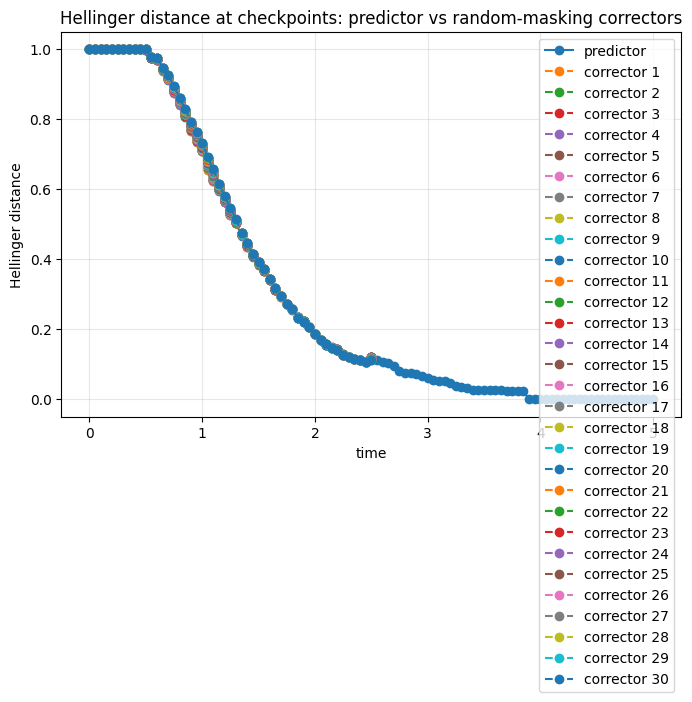

In [48]:
rng = np.random.default_rng(42)
rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(params_RM["n_mc"])]


results_rm = compute_hellinger_over_time(
    w=w,
    mu=mu,
    beta=params_RM["beta"],
    T=params_RM["T"],
    tau=params_RM["tau"],
    checkpoint_every=params_RM["checkpoint_every"],
    n_mc=params_RM["n_mc"],
    rngs=rngs,
    reverse_rng=None,
    MASK=params_RM["MASK"],
    corrector="random_masking",
    tau_c=params_RM["tau_c"],
    n_correctors=params_RM["n_correctors"],
    corrector_start_frac=params_RM["corrector_start_frac"],   
    use_true_pmf_fn=None,      
    unmasking_prob_fn=params_RM["unmasking_prob_fn"],
)

# print_hellinger_summary(results_rm)

plot_hellinger_curves(
    results_rm,
    title="Hellinger distance at checkpoints: predictor vs random-masking correctors"
)

    



# run_name = "randmask_r10_N30_L20_tau001_mc2000"
# pkl_path = save_experiment_artifact(results_rm, params_RM, run_name=run_name)
# append_summary_csv(results_rm, params_RM, run_name=run_name)

# print("saved:", pkl_path)

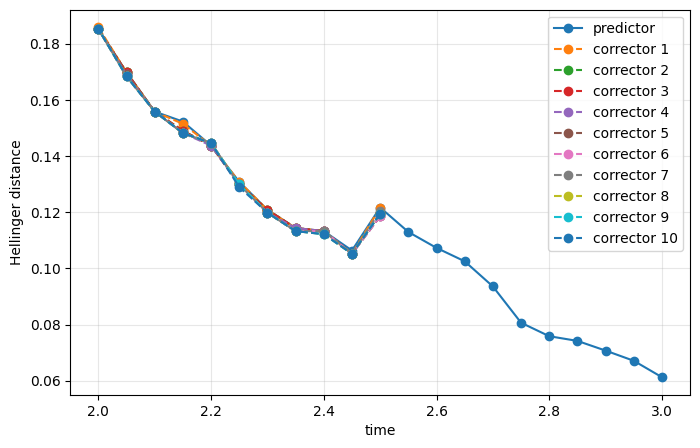

In [29]:
plot_hellinger_curves(results_rm, time_start=2, time_end=3)# 

### PRISM

In [27]:
rng = np.random.default_rng(42)
rngs_forward = [np.random.default_rng(1000 + i) for i in range(params_prism["n_mc"])]
reverse_rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(params_prism["n_mc"])]

results_prism = compute_hellinger_over_time(
    w=w,
    mu=mu,
    beta=params_prism["beta"],
    T=params_prism["T"],
    tau=params_prism["tau"],
    checkpoint_every=params_prism["checkpoint_every"],
    n_mc=params_prism["n_mc"],
    rngs=rngs_forward,
    MASK=params_prism["MASK"],
    corrector="PRISM",
    n_correctors=params_prism["n_correctors"],
    corrector_start_frac=params_prism["corrector_start_frac"],   # only use PRISM in final 20% of reverse time
    use_true_pmf_fn=None,       # or your exact PMF function if you have one
    partial_prob_fn=params_prism["partial_prob_fn"],
    unmasking_prob_fn=params_prism["unmasking_prob_fn"],
    prism_eta=params_prism["prism_eta"],
)

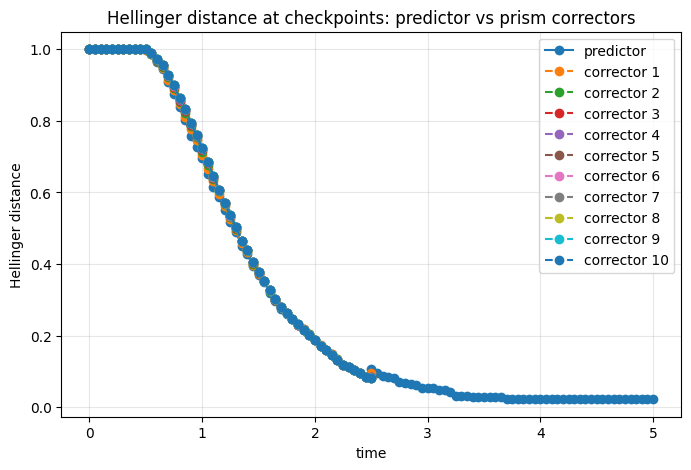

In [49]:


plot_hellinger_curves(
    results_prism,
    title="Hellinger distance at checkpoints: predictor vs prism correctors"
)

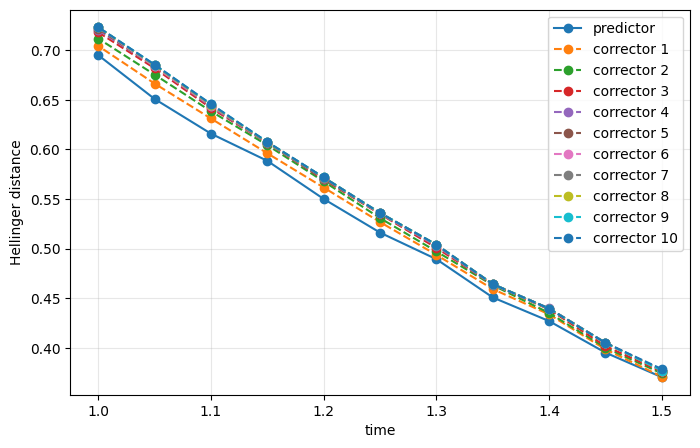

In [36]:
plot_hellinger_curves(results_prism, time_start=1., time_end=1.5
                      )

In [ ]:

run_name = "prism_r10_N30_L20_tau001_mc2000"
pkl_path = save_experiment_artifact(results_prism, params_prism, run_name=run_name)
append_summary_csv(results_prism, params_prism, run_name=run_name)

print("saved:", pkl_path)

## TEST 2

In [37]:
r = 10
N = 30
L = 20
alpha = 0.7

mixture_seed = 0

params_base = {
    "r": r,
    "N": N,
    "L": L,
    "alpha": alpha,
    "beta": 3.0,
    "T": 5.0,
    "tau": 0.01,
    "checkpoint_every": 5,
    "n_mc": 2000,
    "MASK": -1,
    "tau_c": 0.015,
    "prism_remask_frac": 0.3,
    "n_correctors": 30,
    "corrector_start_frac": 0.5,
    "mixture_seed": mixture_seed,
}

w, mu = generate_mixture_parameters_dir(
    r, N, L, alpha, rng=np.random.default_rng(params_base["mixture_seed"])
)

unmasking_prob_fn = make_conditional_prob_fn_mixture(
    w=w,
    mu=mu,
    MASK=params_base["MASK"],
)
params_base["unmasking_prob_fn"] = unmasking_prob_fn


# Random masking parameters
params_RM = params_base.copy()
params_RM["corrector"] = "RandomMasking"
params_RM["tau_c"] = 0.015


# PRISM parameters
partial_prob_fn = make_partial_prob_fn_mixture(
    w=w,
    mu=mu,
    MASK=params_base["MASK"],
)
params_prism = params_base.copy()
params_prism["corrector"] = "PRISM"
params_prism["prism_eta"] = 0.5
params_prism["partial_prob_fn"] = partial_prob_fn




### RM

In [38]:
rng = np.random.default_rng(42)
rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(params_RM["n_mc"])]


results_rm2 = compute_hellinger_over_time(
    w=w,
    mu=mu,
    beta=params_RM["beta"],
    T=params_RM["T"],
    tau=params_RM["tau"],
    checkpoint_every=params_RM["checkpoint_every"],
    n_mc=params_RM["n_mc"],
    rngs=rngs,
    reverse_rng=None,
    MASK=params_RM["MASK"],
    corrector="random_masking",
    tau_c=params_RM["tau_c"],
    n_correctors=params_RM["n_correctors"],
    corrector_start_frac=params_RM["corrector_start_frac"],   
    use_true_pmf_fn=None,      
    unmasking_prob_fn=params_RM["unmasking_prob_fn"],
)

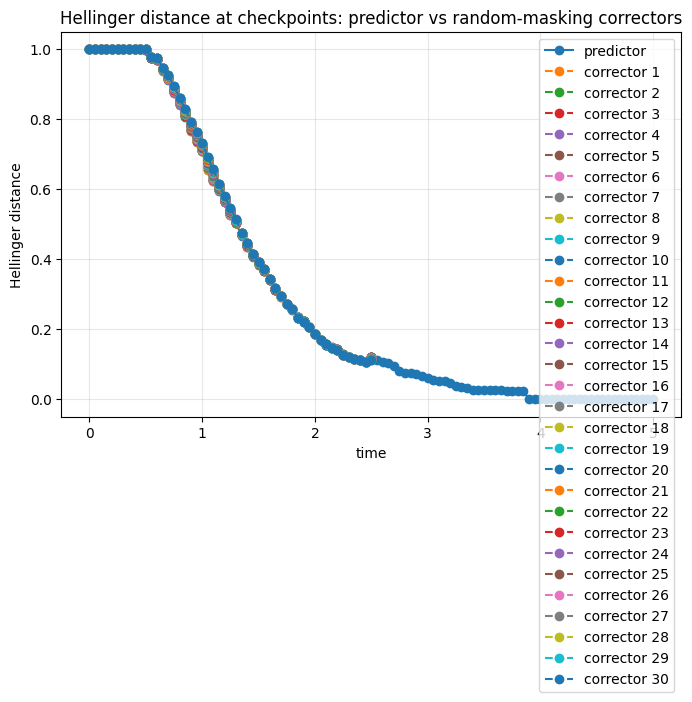

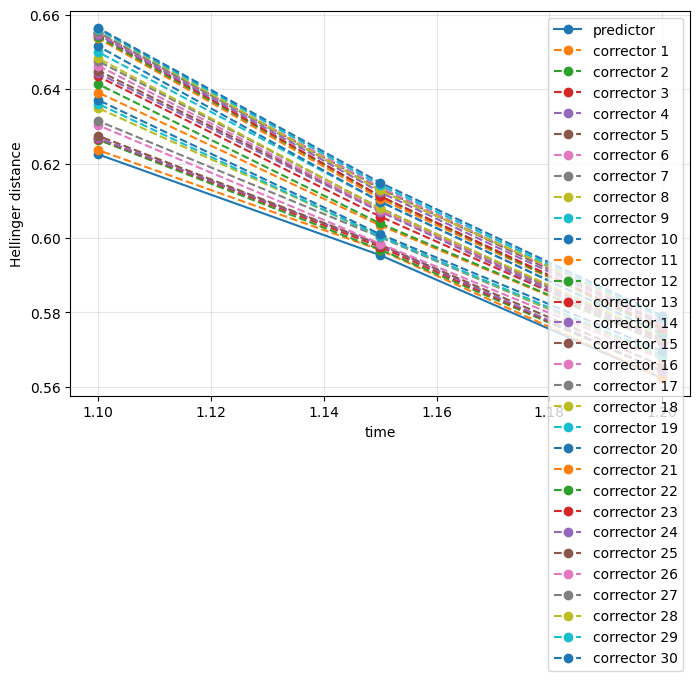

In [45]:
plot_hellinger_curves(
    results_rm2,
    title="Hellinger distance at checkpoints: predictor vs random-masking correctors"
)
plot_hellinger_curves(results_rm2, time_start=1.1, time_end=1.2)


### PRISM

In [40]:
rng = np.random.default_rng(42)
rngs_forward = [np.random.default_rng(1000 + i) for i in range(params_prism["n_mc"])]
reverse_rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(params_prism["n_mc"])]

results_prism2 = compute_hellinger_over_time(
    w=w,
    mu=mu,
    beta=params_prism["beta"],
    T=params_prism["T"],
    tau=params_prism["tau"],
    checkpoint_every=params_prism["checkpoint_every"],
    n_mc=params_prism["n_mc"],
    rngs=rngs_forward,
    MASK=params_prism["MASK"],
    corrector="PRISM",
    n_correctors=params_prism["n_correctors"],
    corrector_start_frac=params_prism["corrector_start_frac"],   # only use PRISM in final 20% of reverse time
    use_true_pmf_fn=None,       # or your exact PMF function if you have one
    partial_prob_fn=params_prism["partial_prob_fn"],
    unmasking_prob_fn=params_prism["unmasking_prob_fn"],
    prism_eta=params_prism["prism_eta"],
)

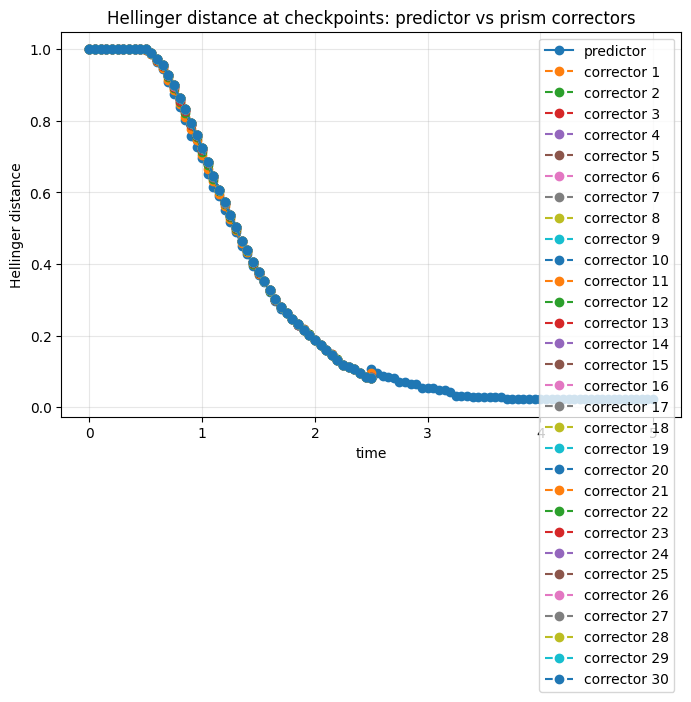

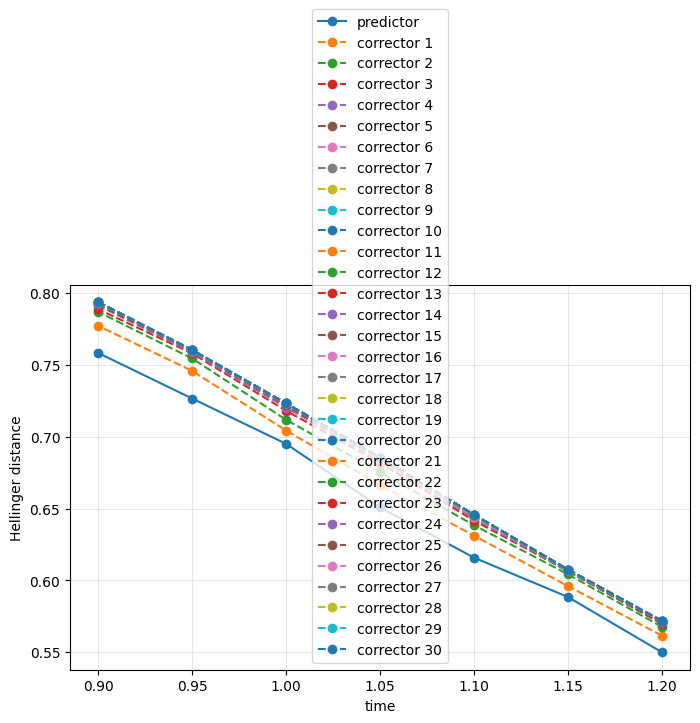

In [47]:

plot_hellinger_curves(
    results_prism2,
    title="Hellinger distance at checkpoints: predictor vs prism correctors"
)
plot_hellinger_curves(results_prism2, time_start=0.9, time_end=1.2)

# Hyperparameter Finetuning

In [18]:


# ------------------------------------------------------------
# 0) BASE SETUP
# ------------------------------------------------------------
# Keep these as in your notebook / current file
r = 10
N = 30
L = 20
alpha = 0.7
mixture_seed = 0

# fixed model/data generation setup
params_base = {
    "r": r,
    "N": N,
    "L": L,
    "alpha": alpha,
    "beta": 3.0,
    "T": 5.0,          # fixed as you requested
    "tau": 0.001,       # baseline predictor step size for stage 1
    "checkpoint_every": 100,
    "n_mc": 500,
    "MASK": -1,
    "n_correctors": 3,
    "corrector_start_frac": 0.5,
    "mixture_seed": mixture_seed,
}

# build mixture once
w, mu = generate_mixture_parameters_dir(
    r=params_base["r"],
    N=params_base["N"],
    L=params_base["L"],
    alpha=params_base["alpha"],
    rng=np.random.default_rng(params_base["mixture_seed"])
)
unmasking_prob_fn = make_conditional_prob_fn_mixture(
    w=w,
    mu=mu,
    MASK=params_base["MASK"],
)
params_base["unmasking_prob_fn"] = unmasking_prob_fn
# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_rng_lists(n_mc, seed):
    """
    Create:
      - forward RNGs: one per particle
      - reverse master RNG
    """
    forward_rngs = [np.random.default_rng(seed + 10000 + i) for i in range(n_mc)]
    reverse_rng = np.random.default_rng(seed + 999999)
    return forward_rngs, reverse_rng


def get_final_predictor_error(results):
    """
    Use predictor error at t=0 if available; otherwise use smallest available t.
    """
    predictor_errors = results.get("predictor_errors", {})
    if 0.0 in predictor_errors:
        return predictor_errors[0.0]
    if len(predictor_errors) == 0:
        return None
    t_min = min(predictor_errors.keys())
    return predictor_errors[t_min]


def get_final_corrector_error(results, n_correctors):
    """
    Prefer corrector error at (t=0, depth=n_correctors).
    If unavailable, use the smallest t and deepest corrector available.
    """
    corrector_errors = results.get("corrector_errors", {})
    if len(corrector_errors) == 0:
        return None

    target_key = (0.0, n_correctors)
    if target_key in corrector_errors:
        return corrector_errors[target_key]

    keys_sorted = sorted(corrector_errors.keys(), key=lambda x: (x[0], -x[1]))
    return corrector_errors[keys_sorted[0]]


def run_one_random_masking_config(config, seed=123, save_artifact=False, artifact_prefix="rm_sweep"):
    """
    Run one random-masking experiment.
    config can override:
      - tau
      - tau_c
      - n_correctors
      - corrector_start_frac
      - checkpoint_every
      - n_mc
    """
    params = deepcopy(params_base)
    params.update(config)

    forward_rngs, reverse_rng = make_rng_lists(params["n_mc"], seed)

    t0 = time.time()
    results = compute_hellinger_over_time(
        w=w,
        mu=mu,
        beta=params["beta"],
        T=params["T"],
        tau=params["tau"],
        checkpoint_every=params["checkpoint_every"],
        n_mc=params["n_mc"],
        rngs=forward_rngs,
        MASK=params["MASK"],
        reverse_rng=reverse_rng,
        corrector="random_masking",
        tau_c=params["tau_c"],
        n_correctors=params["n_correctors"],
        corrector_start_frac=params["corrector_start_frac"],
        use_true_pmf_fn=None,
        unmasking_prob_fn=params["unmasking_prob_fn"],
        prism_eta=None,
        state_values=None,
    )
    runtime_sec = time.time() - t0

    row = {
        "seed": seed,
        "tau": params["tau"],
        "tau_c": params["tau_c"],
        "n_correctors": params["n_correctors"],
        "corrector_start_frac": params["corrector_start_frac"],
        "checkpoint_every": params["checkpoint_every"],
        "n_mc": params["n_mc"],
        "final_predictor_error": get_final_predictor_error(results),
        "final_corrector_error": get_final_corrector_error(results, params["n_correctors"]),
        "runtime_sec": runtime_sec,
    }

    if save_artifact:
        run_name = (
            f"{artifact_prefix}"
            f"_tau{params['tau']}"
            f"_tauc{params['tau_c']}"
            f"_nc{params['n_correctors']}"
            f"_csf{params['corrector_start_frac']}"
        )
        artifact_path = save_experiment_artifact(results, params, run_name=run_name)
        row["artifact_path"] = artifact_path
    else:
        row["artifact_path"] = None

    return results, row


def add_tradeoff_score(df, runtime_weight=0.0005):
    """
    Optional combined score if you want to balance quality + runtime.
    Lower is better.
    """
    out = df.copy()
    out["tradeoff_score"] = out["final_corrector_error"] + runtime_weight * out["runtime_sec"]
    return out


def summarize_top(df, n=10, sort_by="final_corrector_error"):
    cols = [
        "tau", "tau_c", "n_correctors", "corrector_start_frac",
        "final_predictor_error", "final_corrector_error", "runtime_sec"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(sort_by, ascending=True).reset_index(drop=True)[cols].head(n)


# ------------------------------------------------------------
# 2) STAGE 1: TUNE RANDOM MASKING HYPERPARAMETERS
#    Keep tau fixed at baseline = 0.01
# ------------------------------------------------------------
# You can widen or narrow these grids later
rm_grid = {
    "tau_c": [0.005, 0.01,  0.02, 0.03],
    "n_correctors": [1,  5, 10],
    "corrector_start_frac": [0.3, 0.5, 0.7],
}

rm_stage1_configs = []
for tau_c, n_corr, start_frac in itertools.product(
    rm_grid["tau_c"],
    rm_grid["n_correctors"],
    rm_grid["corrector_start_frac"],
):
    rm_stage1_configs.append({
        "tau": 0.001,  # fixed in stage 1
        "tau_c": tau_c,
        "n_correctors": n_corr,
        "corrector_start_frac": start_frac,
    })

rm_stage1_rows = []
rm_stage1_results_store = {}

print(f"Running Stage 1 random masking sweep with {len(rm_stage1_configs)} configs...\n")

for i, cfg in enumerate(rm_stage1_configs, start=1):
    print(f"[Stage 1 | {i}/{len(rm_stage1_configs)}] {cfg}")
    results, row = run_one_random_masking_config(cfg, seed=123, save_artifact=False)
    rm_stage1_rows.append(row)
    rm_stage1_results_store[i - 1] = {
        "config": cfg,
        "results": results,
    }

rm_stage1_df = pd.DataFrame(rm_stage1_rows)
rm_stage1_df = rm_stage1_df.sort_values("final_corrector_error", ascending=True).reset_index(drop=True)

print("\nTop Stage 1 configs:")
display(summarize_top(rm_stage1_df, n=10))

# Optional runtime-quality score
rm_stage1_scored_df = add_tradeoff_score(rm_stage1_df, runtime_weight=0.0005)
print("\nTop Stage 1 configs by tradeoff score:")
display(rm_stage1_scored_df.sort_values("tradeoff_score", ascending=True).reset_index(drop=True).head(10))


# ------------------------------------------------------------
# 3) PLOT BEST STAGE 1 RESULT
# ------------------------------------------------------------
best_stage1_cfg = {
    "tau": float(rm_stage1_df.iloc[0]["tau"]),
    "tau_c": float(rm_stage1_df.iloc[0]["tau_c"]),
    "n_correctors": int(rm_stage1_df.iloc[0]["n_correctors"]),
    "corrector_start_frac": float(rm_stage1_df.iloc[0]["corrector_start_frac"]),
}

print("Best Stage 1 config:")
print(best_stage1_cfg)

best_stage1_results, best_stage1_row = run_one_random_masking_config(
    best_stage1_cfg,
    seed=123,
    save_artifact=False
)

print("\nBest Stage 1 summary row:")
print(best_stage1_row)

print_hellinger_summary(best_stage1_results)
plot_hellinger_curves(best_stage1_results, title="Best Stage 1 random masking config")




Running Stage 1 random masking sweep with 36 configs...

[Stage 1 | 1/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 1, 'corrector_start_frac': 0.3}
[Stage 1 | 2/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 1, 'corrector_start_frac': 0.5}
[Stage 1 | 3/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 1, 'corrector_start_frac': 0.7}
[Stage 1 | 4/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 5, 'corrector_start_frac': 0.3}
[Stage 1 | 5/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 5, 'corrector_start_frac': 0.5}
[Stage 1 | 6/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 5, 'corrector_start_frac': 0.7}
[Stage 1 | 7/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 10, 'corrector_start_frac': 0.3}
[Stage 1 | 8/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 10, 'corrector_start_frac': 0.5}
[Stage 1 | 9/36] {'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 10, 'corrector_start_frac': 0.7}
[Stage 1 | 10/36] {'tau': 0.001, 'tau_c': 0.01, 'n_correctors': 1, 'correcto

,tau,tau_c,n_correctors,corrector_start_frac,final_predictor_error,final_corrector_error,runtime_sec
0,0.001,0.005,1,0.3,1.0,1.0,530.573661
1,0.001,0.005,1,0.7,1.0,1.0,535.215727
2,0.001,0.005,5,0.3,1.0,1.0,538.697377
3,0.001,0.005,5,0.5,1.0,1.0,538.770384
4,0.001,0.005,5,0.7,1.0,1.0,542.813319
5,0.001,0.005,10,0.3,1.0,1.0,541.417047
6,0.001,0.005,10,0.5,1.0,1.0,551.280090
7,0.001,0.005,1,0.5,1.0,1.0,537.701880
8,0.001,0.005,10,0.7,1.0,1.0,582.435732
9,0.001,0.010,1,0.5,1.0,1.0,554.374753



Top Stage 1 configs by tradeoff score:


,seed,tau,tau_c,n_correctors,corrector_start_frac,checkpoint_every,n_mc,final_predictor_error,final_corrector_error,runtime_sec,artifact_path,tradeoff_score
0,123,0.001,0.005,1,0.3,100,500,1.0,1.0,530.573661,None,1.265287
1,123,0.001,0.030,1,0.3,100,500,1.0,1.0,530.792790,None,1.265396
2,123,0.001,0.030,1,0.5,100,500,1.0,1.0,534.986372,None,1.267493
3,123,0.001,0.005,1,0.7,100,500,1.0,1.0,535.215727,None,1.267608
4,123,0.001,0.030,1,0.7,100,500,1.0,1.0,537.526298,None,1.268763
5,123,0.001,0.005,1,0.5,100,500,1.0,1.0,537.701880,None,1.268851
6,123,0.001,0.005,5,0.3,100,500,1.0,1.0,538.697377,None,1.269349
7,123,0.001,0.005,5,0.5,100,500,1.0,1.0,538.770384,None,1.269385
8,123,0.001,0.030,5,0.3,100,500,1.0,1.0,540.694781,None,1.270347
9,123,0.001,0.020,5,0.3,100,500,1.0,1.0,541.179744,None,1.270590


Best Stage 1 config:
{'tau': 0.001, 'tau_c': 0.005, 'n_correctors': 1, 'corrector_start_frac': 0.3}


KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------------------
# 4) STAGE 2: TUNE TAU WITH BEST RANDOM MASKING SETTINGS FIXED
# ------------------------------------------------------------
tau_grid = [0.0005,0.005, 0.01, 0.04]

rm_stage2_configs = []
for tau_val in tau_grid:
    cfg = dict(best_stage1_cfg)
    cfg["tau"] = tau_val
    rm_stage2_configs.append(cfg)

rm_stage2_rows = []
rm_stage2_results_store = {}

print(f"\nRunning Stage 2 tau sweep with {len(rm_stage2_configs)} configs...\n")

for i, cfg in enumerate(rm_stage2_configs, start=1):
    print(f"[Stage 2 | {i}/{len(rm_stage2_configs)}] {cfg}")
    results, row = run_one_random_masking_config(cfg, seed=123, save_artifact=False)
    rm_stage2_rows.append(row)
    rm_stage2_results_store[i - 1] = {
        "config": cfg,
        "results": results,
    }

rm_stage2_df = pd.DataFrame(rm_stage2_rows)
rm_stage2_df = rm_stage2_df.sort_values("final_corrector_error", ascending=True).reset_index(drop=True)

print("\nTop Stage 2 tau configs:")
display(summarize_top(rm_stage2_df, n=10))

rm_stage2_scored_df = add_tradeoff_score(rm_stage2_df, runtime_weight=0.0005)
print("\nTop Stage 2 tau configs by tradeoff score:")
display(rm_stage2_scored_df.sort_values("tradeoff_score", ascending=True).reset_index(drop=True).head(10))


# ------------------------------------------------------------
# 5) PLOT BEST STAGE 2 RESULT
# ------------------------------------------------------------
best_stage2_cfg = {
    "tau": float(rm_stage2_df.iloc[0]["tau"]),
    "tau_c": float(rm_stage2_df.iloc[0]["tau_c"]),
    "n_correctors": int(rm_stage2_df.iloc[0]["n_correctors"]),
    "corrector_start_frac": float(rm_stage2_df.iloc[0]["corrector_start_frac"]),
}

print("Best Stage 2 config:")
print(best_stage2_cfg)

best_stage2_results, best_stage2_row = run_one_random_masking_config(
    best_stage2_cfg,
    seed=123,
    save_artifact=False
)

print("\nBest Stage 2 summary row:")
print(best_stage2_row)

print_hellinger_summary(best_stage2_results)
plot_hellinger_curves(best_stage2_results, title="Best Stage 2 random masking + tau config")


# ------------------------------------------------------------
# 6) OPTIONAL: FINE TAU SWEEP AROUND THE WINNER
# ------------------------------------------------------------
best_tau = float(rm_stage2_df.iloc[0]["tau"])

tau_fine_candidates = sorted(set([
    max(1e-4, best_tau * 0.5),
    max(1e-4, best_tau * 0.75),
    best_tau,
    best_tau * 1.25,
    best_tau * 1.5,
]))

rm_stage3_configs = []
for tau_val in tau_fine_candidates:
    cfg = dict(best_stage2_cfg)
    cfg["tau"] = tau_val
    rm_stage3_configs.append(cfg)

rm_stage3_rows = []

print(f"\nRunning optional fine tau sweep with {len(rm_stage3_configs)} configs...\n")

for i, cfg in enumerate(rm_stage3_configs, start=1):
    print(f"[Stage 3 | {i}/{len(rm_stage3_configs)}] {cfg}")
    _, row = run_one_random_masking_config(cfg, seed=321, save_artifact=False)
    rm_stage3_rows.append(row)

rm_stage3_df = pd.DataFrame(rm_stage3_rows)
rm_stage3_df = rm_stage3_df.sort_values("final_corrector_error", ascending=True).reset_index(drop=True)

print("\nTop Stage 3 fine tau configs:")
display(summarize_top(rm_stage3_df, n=10))


# ------------------------------------------------------------
# 7) OPTIONAL: MULTI-SEED CHECK FOR THE FINAL CONFIG
# ------------------------------------------------------------
def evaluate_config_over_seeds(config, seeds=(11, 22, 33)):
    rows = []
    for seed in seeds:
        _, row = run_one_random_masking_config(config, seed=seed, save_artifact=False)
        rows.append(row)
    df = pd.DataFrame(rows)
    summary = {
        "tau": config["tau"],
        "tau_c": config["tau_c"],
        "n_correctors": config["n_correctors"],
        "corrector_start_frac": config["corrector_start_frac"],
        "mean_final_predictor_error": df["final_predictor_error"].mean(),
        "std_final_predictor_error": df["final_predictor_error"].std(ddof=1),
        "mean_final_corrector_error": df["final_corrector_error"].mean(),
        "std_final_corrector_error": df["final_corrector_error"].std(ddof=1),
        "mean_runtime_sec": df["runtime_sec"].mean(),
    }
    return df, summary


# choose final config:
if "rm_stage3_df" in globals() and len(rm_stage3_df) > 0:
    final_cfg = {
        "tau": float(rm_stage3_df.iloc[0]["tau"]),
        "tau_c": float(rm_stage3_df.iloc[0]["tau_c"]),
        "n_correctors": int(rm_stage3_df.iloc[0]["n_correctors"]),
        "corrector_start_frac": float(rm_stage3_df.iloc[0]["corrector_start_frac"]),
    }
else:
    final_cfg = best_stage2_cfg

print("\nFinal candidate config for multi-seed check:")
print(final_cfg)

final_seed_df, final_seed_summary = evaluate_config_over_seeds(final_cfg, seeds=(11, 22, 33))

print("\nPer-seed results:")
display(final_seed_df)

print("\nFinal multi-seed summary:")
print(final_seed_summary)


# ------------------------------------------------------------
# 8) OPTIONAL: SAVE FINAL RUN
# ------------------------------------------------------------
final_results, final_row = run_one_random_masking_config(
    final_cfg,
    seed=999,
    save_artifact=True,
    artifact_prefix="final_random_masking_tuned"
)

print("\nSaved final run summary:")
print(final_row)

print("\nDone.")